# Agentic RAG

In [ ]:
#libraries
import os
from dotenv import load_dotenv
load_dotenv()

True

In [3]:
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter

loading data from langgraph blogs and splitting into chunks

In [7]:
# langgraph urls
urls=[
    "https://langchain-ai.github.io/langgraph/tutorials/introduction/",
    "https://langchain-ai.github.io/langgraph/tutorials/workflows/",
    "https://langchain-ai.github.io/langgraph/how-tos/map-reduce/"
]
docs = [WebBaseLoader(url).load() for url in urls]
docs


[[Document(metadata={'source': 'https://langchain-ai.github.io/langgraph/tutorials/introduction/', 'title': 'Redirecting...', 'language': 'en'}, page_content='\n\n\n\nRedirecting...\n\n\n\n\n\n\nRedirecting...\n\n\n')],
 [Document(metadata={'source': 'https://langchain-ai.github.io/langgraph/tutorials/workflows/', 'title': 'Redirecting...', 'language': 'en'}, page_content='\n\n\n\nRedirecting...\n\n\n\n\n\n\nRedirecting...\n\n\n')],
 [Document(metadata={'source': 'https://langchain-ai.github.io/langgraph/how-tos/map-reduce/', 'title': 'Redirecting...', 'language': 'en'}, page_content='\n\n\n\nRedirecting...\n\n\n\n\n\n\nRedirecting...\n\n\n')]]

In [8]:
doc_list = [doc for sublist in docs for doc in sublist]
doc_list

[Document(metadata={'source': 'https://langchain-ai.github.io/langgraph/tutorials/introduction/', 'title': 'Redirecting...', 'language': 'en'}, page_content='\n\n\n\nRedirecting...\n\n\n\n\n\n\nRedirecting...\n\n\n'),
 Document(metadata={'source': 'https://langchain-ai.github.io/langgraph/tutorials/workflows/', 'title': 'Redirecting...', 'language': 'en'}, page_content='\n\n\n\nRedirecting...\n\n\n\n\n\n\nRedirecting...\n\n\n'),
 Document(metadata={'source': 'https://langchain-ai.github.io/langgraph/how-tos/map-reduce/', 'title': 'Redirecting...', 'language': 'en'}, page_content='\n\n\n\nRedirecting...\n\n\n\n\n\n\nRedirecting...\n\n\n')]

In [9]:
text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000,chunk_overlap=100)
doc_splits = text_splitter.split_documents(doc_list)
doc_splits


[Document(metadata={'source': 'https://langchain-ai.github.io/langgraph/tutorials/introduction/', 'title': 'Redirecting...', 'language': 'en'}, page_content='Redirecting...\n\n\n\n\n\n\nRedirecting...'),
 Document(metadata={'source': 'https://langchain-ai.github.io/langgraph/tutorials/workflows/', 'title': 'Redirecting...', 'language': 'en'}, page_content='Redirecting...\n\n\n\n\n\n\nRedirecting...'),
 Document(metadata={'source': 'https://langchain-ai.github.io/langgraph/how-tos/map-reduce/', 'title': 'Redirecting...', 'language': 'en'}, page_content='Redirecting...\n\n\n\n\n\n\nRedirecting...')]

building the vectordb and retriever for langgraph docs

In [11]:
embedding = HuggingFaceEmbeddings(model="all-MiniLM-L6-v2")
embedding

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

HuggingFaceEmbeddings(model_name='all-MiniLM-L6-v2', cache_folder=None, model_kwargs={}, encode_kwargs={}, query_encode_kwargs={}, multi_process=False, show_progress=False)

In [12]:
vectorstore = FAISS.from_documents(
    documents=doc_splits,
    embedding=embedding
)
retriever = vectorstore.as_retriever()

In [13]:
retriever.invoke("What is langgraph?")

[Document(id='ef0c9a25-2f5a-42ea-a6e7-897b5f4ca4d1', metadata={'source': 'https://langchain-ai.github.io/langgraph/tutorials/introduction/', 'title': 'Redirecting...', 'language': 'en'}, page_content='Redirecting...\n\n\n\n\n\n\nRedirecting...'),
 Document(id='aaa7041e-b329-4229-8c2d-7a6cf5094c7f', metadata={'source': 'https://langchain-ai.github.io/langgraph/tutorials/workflows/', 'title': 'Redirecting...', 'language': 'en'}, page_content='Redirecting...\n\n\n\n\n\n\nRedirecting...'),
 Document(id='99db9a37-45a6-4e13-b4c5-df7940ec7dcf', metadata={'source': 'https://langchain-ai.github.io/langgraph/how-tos/map-reduce/', 'title': 'Redirecting...', 'language': 'en'}, page_content='Redirecting...\n\n\n\n\n\n\nRedirecting...')]

Retriever Tool for langgraph

In [17]:
from langchain_core.tools import create_retriever_tool
retriever_tool = create_retriever_tool(
    retriever=retriever,
    name="retriever_vector_langgraph_blog",
    description="Search and get infromation about Langgraph"
)
retriever_tool

StructuredTool(name='retriever_vector_langgraph_blog', description='Search and get infromation about Langgraph', args_schema=<class 'langchain_core.tools.retriever.RetrieverInput'>, func=<function create_retriever_tool.<locals>.func at 0x000002AD01D17380>, coroutine=<function create_retriever_tool.<locals>.afunc at 0x000002AD04498360>)

loading data from langchain blogs and splitting into chunks

In [15]:
# langgraph urls
urls=[
    "https://python.langchain.com/docs/tutorials/",
    "https://python.langchain.com/docs/tutorials/chatbot/",
    "https://python.langchain.com/docs/tutorials/qa_chat_history"
]
docs = [WebBaseLoader(url).load() for url in urls]
doc_list = [doc for sublist in docs for doc in sublist]
doc_splits = text_splitter.split_documents(doc_list)

building the vectordb and retriever for langgraph docs

In [16]:
vectorstore2 = FAISS.from_documents(
    documents=doc_splits,
    embedding=embedding
)
retriever2 = vectorstore2.as_retriever()

Retriever Tool for langchain

In [18]:
retriever_tool_2 = create_retriever_tool(
    retriever=retriever2,
    name="retriever_vector_langchain_blog",
    description="Search and get infromation about Langchain"
)
retriever_tool_2

StructuredTool(name='retriever_vector_langchain_blog', description='Search and get infromation about Langchain', args_schema=<class 'langchain_core.tools.retriever.RetrieverInput'>, func=<function create_retriever_tool.<locals>.func at 0x000002AD04498680>, coroutine=<function create_retriever_tool.<locals>.afunc at 0x000002AD044985E0>)

In [19]:
tools=[retriever_tool,retriever_tool_2]

Langgraph Workflow

In [20]:
from typing import Annotated,Sequence
from typing_extensions import TypedDict
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages

class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage],add_messages]

initializing the LLM

In [43]:
from langchain_groq import ChatGroq
llm = ChatGroq(model="llama-3.1-8b-instant")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000002AD24519BE0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002AD2451B620>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [45]:
def agent(state: AgentState):
    """Invokes the agent model to generate a response based on current state.
    Given the question,it will decide to retrieve using the retriever tool or simply end
    Args:
       state (messages): the current state
    Returns:
       dict: The updated state with the agent response appended to messages
    """
    messages = state['messages']
    model = ChatGroq(model="llama-3.1-8b-instant")
    model = model.bind_tools(tools)
    response = model.invoke(messages)
    return {'messages':[response]}

In [26]:
from langchain_classic import hub
from langchain_core.messages import BaseMessage,HumanMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate
from pydantic import BaseModel, Field
from typing import Annotated,Literal,Sequence
from typing_extensions import TypedDict

In [46]:
def grade_documents(state: AgentState) -> Literal["generate","rewrite"]:
    """Determines whether the retrieved documents are relevant to the question.
    Args:
       state (messages): The current state
    Returns:
       str: A decision for whether the documents are relevant or not
    """
    class grade(BaseModel):
        binary_score: str = Field(description="Relevance score 'yes' or 'no")
    
    model = ChatGroq(model="llama-3.1-8b-instant")

    llm_with_tool = model.with_structured_output(grade)

    prompt = PromptTemplate(
        template="""You are grader assessing relevance of a retrieved document to a user question.\n
        Here is the retrieved document:\n\n{context}\n\n
        Here is the user question: {question}\n
        If the document contains keyword(s) or semantic meaning related to the user question, grade it as relevant.\n
        Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question.""",
        input_variables=["context","question"]
    )
    chain = prompt | llm_with_tool
    messages = state['messages']
    last_message = messages[-1]

    question = messages[0].content
    docs = last_message.content
    
    scored_result = chain.invoke({"question":question,"context":docs})
    score = scored_result.binary_score
    if score=="yes":
        return "generate"
    else:
        return "rewrite"


In [58]:
def generate(state: AgentState):
    """Generate Answer
    Args:
       state (messages): The current state
    Returns:
       dict: the updated message
    """
    messages = state['messages']
    question = messages[0].content
    last_message=messages[-1]
    docs = last_message.content

    prompt = hub.pull("rlm/rag-prompt")
    llm = ChatGroq(model="llama-3.1-8b-instant")

    def format_docs(docs):
        return "\n\n".join(doc.page_content for doc in docs)
    
    rag_chain = prompt | llm | StrOutputParser()
    response = rag_chain.invoke({"context":docs,"question":question})
    return {'messages':[response]}

In [55]:
def rewrite(state: AgentState):
    """Transform the query to produce a better question
    Args:
       state (messages): The current state
    Returns:
       dict: the updated state with re-phrased question
    """
    messages = state['messages']
    question = messages[0].content
    msg = [
        HumanMessage(
            content=f"""\n
Look at the input and try to reason about the underlying semantic intent/meaning.\n Here is the initial question:
\n ------ \n
{question}
\n ------ \n
Formulate an improved question:"""
        )
    ]
    model = ChatGroq(model="llama-3.1-8b-instant")
    response = model.invoke(msg)
    return {"messages":[response]}

building the StateGraph

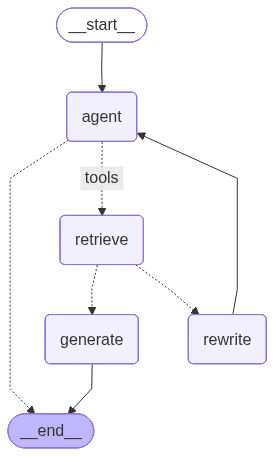

In [56]:
from langgraph.graph import START,END,StateGraph
from langgraph.prebuilt import ToolNode,tools_condition

workflow=StateGraph(AgentState)

workflow.add_node("agent",agent)
workflow.add_node("retrieve",ToolNode(tools=tools))
workflow.add_node("rewrite",rewrite)
workflow.add_node("generate",generate)

workflow.add_edge(START,"agent")
workflow.add_conditional_edges(
    "agent",
    tools_condition,
    {
        "tools":"retrieve",
        END:END
    }
    )
workflow.add_conditional_edges("retrieve",grade_documents)
workflow.add_edge("generate",END)
workflow.add_edge("rewrite","agent")

graph = workflow.compile()
graph

testing the graph

In [59]:
graph.invoke({"messages":"What is Langchain?"})

{'messages': [HumanMessage(content='What is Langchain?', additional_kwargs={}, response_metadata={}, id='b14015f2-67d5-4c1a-9632-7efacd0ef1c5'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'twbsgdwt9', 'function': {'arguments': '{"query":"What is Langchain?"}', 'name': 'retriever_vector_langchain_blog'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 22, 'prompt_tokens': 320, 'total_tokens': 342, 'completion_time': 0.024037329, 'completion_tokens_details': None, 'prompt_time': 0.021480318, 'prompt_tokens_details': None, 'queue_time': 0.047334802, 'total_time': 0.045517647}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f2d52-3d0e-7893-a797-d51d111868cf-0', tool_calls=[{'name': 'retriever_vector_langchain_blog', 'args': {'query': 'What is Langchain?'}, 'id': 'twbsgdwt9', 'type': 'tool_c